In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Social Media Project.csv")

In [3]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Engagement,Month Name
0,Enjoying a beautiful day at the park! ...,Positive,15-01-2023 12.30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,45,January
1,Traffic was terrible this morning. ...,Negative,15-01-2023 8.45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,15,January
2,Just finished an amazing workout! ðŸ’ª ...,Positive,15-01-2023 15.45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15,60,January
3,Excited about the upcoming weekend getaway! ...,Positive,15-01-2023 18.20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18,23,January
4,Trying out a new recipe for dinner tonight. ...,Neutral,15-01-2023 19.55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19,37,January


In [4]:
df.tail()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Engagement,Month Name
727,Collaborating on a science project that receiv...,Happy,18-08-2017 18.20,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20,39,UK,2017,8,18,18,59,August
728,Attending a surprise birthday party organized ...,Happy,22-06-2018 14.15,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25,48,USA,2018,6,22,14,73,June
729,Successfully fundraising for a school charity ...,Happy,05-04-2019 17.30,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22,42,Canada,2019,4,5,17,64,April
730,"Participating in a multicultural festival, cel...",Happy,29-02-2020 20.45,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21,43,UK,2020,2,29,20,64,February
731,Organizing a virtual talent show during challe...,Happy,15-11-2020 15.15,VirtualTalentShowSuccessHighSchool,Instagram,#VirtualEntertainment #HighSchoolPositivity,24,47,USA,2020,11,15,15,71,November


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text        732 non-null    object
 1   Sentiment   732 non-null    object
 2   Timestamp   732 non-null    object
 3   User        732 non-null    object
 4   Platform    732 non-null    object
 5   Hashtags    732 non-null    object
 6   Retweets    732 non-null    int64 
 7   Likes       732 non-null    int64 
 8   Country     732 non-null    object
 9   Year        732 non-null    int64 
 10  Month       732 non-null    int64 
 11  Day         732 non-null    int64 
 12  Hour        732 non-null    int64 
 13  Engagement  732 non-null    int64 
 14  Month Name  732 non-null    object
dtypes: int64(7), object(8)
memory usage: 85.9+ KB


In [6]:
df.isnull().sum()

Text          0
Sentiment     0
Timestamp     0
User          0
Platform      0
Hashtags      0
Retweets      0
Likes         0
Country       0
Year          0
Month         0
Day           0
Hour          0
Engagement    0
Month Name    0
dtype: int64

In [7]:
df.dropna(inplace = True)

In [10]:
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

In [11]:
df['Engagement'] = df['Likes'] + df['Retweets']

In [12]:
platform_engagement = df.groupby('Platform')['Engagement'].sum()

print(platform_engagement)

Platform
Facebook     14516
Instagram    17464
Twitter      15168
Name: Engagement, dtype: int64


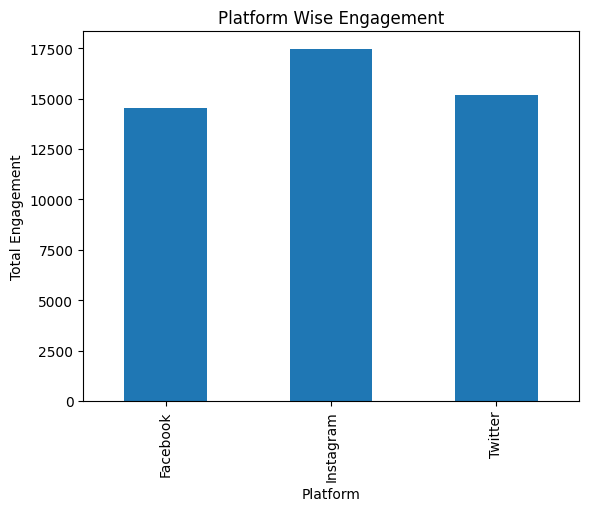

In [13]:
platform_engagement.plot(kind = 'bar')

plt.title("Platform Wise Engagement")
plt.xlabel("Platform")
plt.ylabel("Total Engagement")

plt.show()

In [14]:
sentiment_count = df['Sentiment'].value_counts()

print(sentiment_count)

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


In [15]:
best_hour = df.groupby('Hour')['Engagement'].mean()

print(best_hour)

Hour
0     53.000000
2     54.000000
3     54.000000
5     83.000000
6     52.250000
7     61.857143
8     61.347826
9     55.321429
10    62.833333
11    56.567568
12    61.710526
13    68.766667
14    62.468085
15    60.744681
16    58.855072
17    63.708333
18    67.492308
19    67.093333
20    74.780000
21    65.975610
22    75.878788
23    85.000000
Name: Engagement, dtype: float64


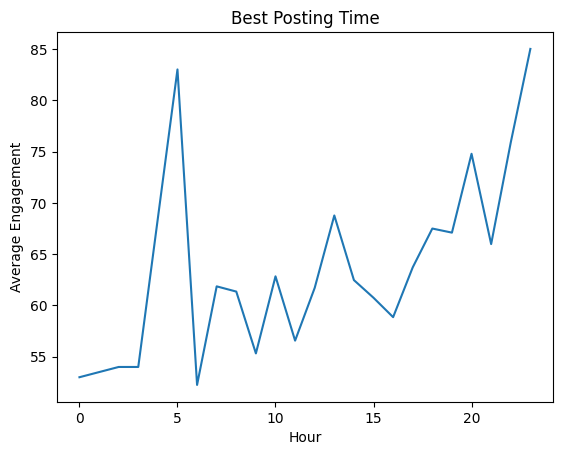

In [16]:
best_hour.plot(kind = 'line')

plt.title("Best Posting Time")
plt.xlabel("Hour")
plt.ylabel("Average Engagement")

plt.show()

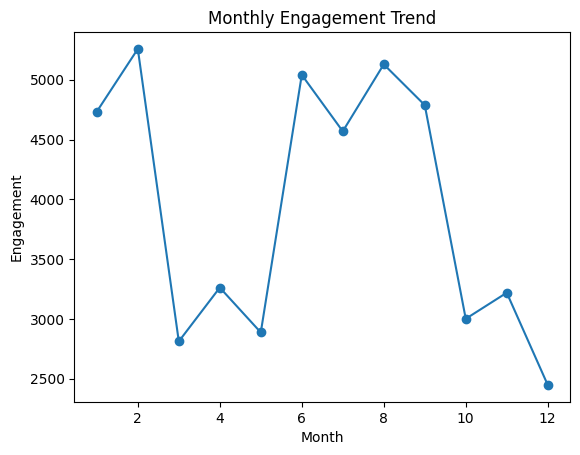

In [17]:
monthly = df.groupby('Month')['Engagement'].sum()

monthly.plot(kind = 'line', marker = 'o')

plt.title("Monthly Engagement Trend")
plt.xlabel("Month")
plt.ylabel("Engagement")

plt.show()

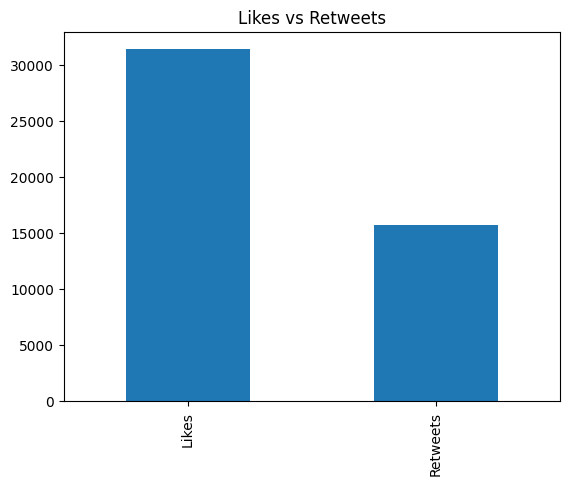

In [ ]:
comparison = df[['Likes', 'Retweets']].sum()

comparison.plot(kind = 'bar')

plt.title("Likes vs Retweets")

plt.show()

In [19]:
df.to_csv("cleaned_social_media.csv", index = False)